# Hydrogen bound states on a Laguerre mesh

This notebook illustrates the bound-state workflow for hydrogen with the regularized-Laguerre mesh.

We will:

1. solve for several low-lying bound states,
2. compare numerical and analytic energies,
3. visualize selected wavefunctions in real space,
4. visualize the same states in momentum space.


In [1]:
from __future__ import annotations

import math

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy.special as sc

import lax as lm

HBAR2_2MU = 0.5


In [2]:
def hydrogen_solver(angular_momentum: int) -> lm.boundary._types.Solver:
    return lm.compile(
        mesh=lm.MeshSpec("laguerre", "x", n=30, scale=2.0),
        channels=(lm.ChannelSpec(l=angular_momentum, threshold=0.0, mass_factor=HBAR2_2MU),),
        operators=("T", "1/r"),
        solvers=("spectrum", "wavefunction"),
        grid=jnp.linspace(0.0, 40.0, 3000),
        momenta=jnp.linspace(0.0, 6.0, 500),
    )


def hydrogen_potential(solver: lm.boundary._types.Solver) -> jnp.ndarray:
    return jnp.asarray((-1.0 / solver.mesh.radii)[None, None, :])


def radial_u_analytic(n: int, angular_momentum: int, radii: np.ndarray) -> np.ndarray:
    rho = 2.0 * radii / float(n)
    prefactor = 2.0 / (n**2) * math.sqrt(
        math.factorial(n - angular_momentum - 1) / math.factorial(n + angular_momentum)
    )
    radial = (
        prefactor
        * np.exp(-0.5 * rho)
        * rho**angular_momentum
        * sc.eval_genlaguerre(n - angular_momentum - 1, 2 * angular_momentum + 1, rho)
    )
    return radii * radial


def momentum_u_analytic(n: int, angular_momentum: int, momenta: np.ndarray) -> np.ndarray:
    if n == 1 and angular_momentum == 0:
        return np.sqrt(2.0 / np.pi) * 2.0 / (1.0 + momenta**2)
    if n == 2 and angular_momentum == 0:
        denominator = momenta**2 + 0.25
        return np.sqrt(1.0 / np.pi) * (momenta**2 - 0.25) / (denominator**2)
    if n == 2 and angular_momentum == 1:
        denominator = momenta**2 + 0.25
        return np.sqrt(2.0 / (6.0 * np.pi)) * momenta / (denominator**2)
    raise ValueError(f"No analytic momentum-space form for (n, l)=({n}, {angular_momentum}).")


def normalized_and_aligned(numerical: np.ndarray, analytic: np.ndarray, grid: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    numerical_norm = math.sqrt(float(np.trapezoid(np.abs(numerical) ** 2, grid)))
    analytic_norm = math.sqrt(float(np.trapezoid(np.abs(analytic) ** 2, grid)))
    numerical_normalized = numerical / numerical_norm
    analytic_normalized = analytic / analytic_norm
    overlap = float(np.trapezoid(numerical_normalized * analytic_normalized, grid))
    sign = -1.0 if overlap < 0.0 else 1.0
    return sign * numerical_normalized, analytic_normalized


In [3]:
solver_s = hydrogen_solver(0)
solver_p = hydrogen_solver(1)

spectrum_s = solver_s.spectrum(hydrogen_potential(solver_s))
spectrum_p = solver_p.spectrum(hydrogen_potential(solver_p))

energy_rows = [
    ("1s", float(np.asarray(spectrum_s.eigenvalues)[0]) * HBAR2_2MU, -0.5),
    ("2s", float(np.asarray(spectrum_s.eigenvalues)[1]) * HBAR2_2MU, -0.125),
    ("3s", float(np.asarray(spectrum_s.eigenvalues)[2]) * HBAR2_2MU, -1.0 / 18.0),
    ("2p", float(np.asarray(spectrum_p.eigenvalues)[0]) * HBAR2_2MU, -0.125),
    ("3p", float(np.asarray(spectrum_p.eigenvalues)[1]) * HBAR2_2MU, -1.0 / 18.0),
]

print("State   numerical        analytic         abs error")
for label, numerical, analytic in energy_rows:
    print(f"{label:>3}   {numerical: .10f}   {analytic: .10f}   {abs(numerical - analytic):.3e}")


State   numerical        analytic         abs error
 1s   -0.5000000000   -0.5000000000   2.896e-11
 2s   -0.1250000000   -0.1250000000   8.327e-17
 3s   -0.0555555556   -0.0555555556   1.041e-16
 2p   -0.1250000000   -0.1250000000   1.943e-16
 3p   -0.0555555556   -0.0555555556   2.776e-17


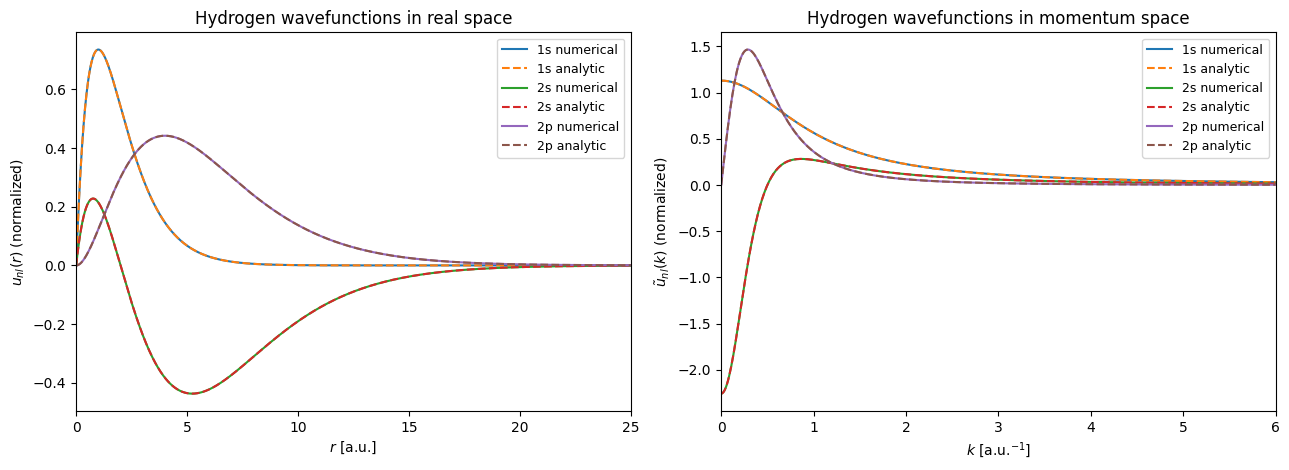

In [4]:
radii_s = np.asarray(solver_s.transforms.grid_r)
momenta_s = np.asarray(solver_s.transforms.momenta)
radii_p = np.asarray(solver_p.transforms.grid_r)
momenta_p = np.asarray(solver_p.transforms.momenta)

states = [
    ("1s", solver_s, spectrum_s, 0, 1, 0),
    ("2s", solver_s, spectrum_s, 1, 2, 0),
    ("2p", solver_p, spectrum_p, 0, 2, 1),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for label, solver, spectrum, state_index, n, angular_momentum in states:
    coeffs = np.asarray(spectrum.eigenvectors)[:, state_index]
    radii = np.asarray(solver.transforms.grid_r)
    momenta = np.asarray(solver.transforms.momenta)
    numerical_r = np.asarray(solver.to_grid_vector(jnp.asarray(coeffs)))
    analytic_r = radial_u_analytic(n, angular_momentum, radii)
    aligned_r, analytic_r = normalized_and_aligned(numerical_r, analytic_r, radii)
    axes[0].plot(radii, aligned_r, label=f"{label} numerical")
    axes[0].plot(radii, analytic_r, "--", label=f"{label} analytic")

    numerical_k = np.asarray(solver.fourier(jnp.asarray(coeffs)))
    analytic_k = momentum_u_analytic(n, angular_momentum, momenta)
    aligned_k, analytic_k = normalized_and_aligned(numerical_k, analytic_k, momenta)
    axes[1].plot(momenta, aligned_k, label=f"{label} numerical")
    axes[1].plot(momenta, analytic_k, "--", label=f"{label} analytic")

axes[0].set_title("Hydrogen wavefunctions in real space")
axes[0].set_xlabel(r"$r$ [a.u.]")
axes[0].set_ylabel(r"$u_{nl}(r)$ (normalized)")
axes[0].set_xlim(0.0, 25.0)

axes[1].set_title("Hydrogen wavefunctions in momentum space")
axes[1].set_xlabel(r"$k$ [a.u.$^{-1}$]")
axes[1].set_ylabel(r"$\tilde u_{nl}(k)$ (normalized)")
axes[1].set_xlim(0.0, 6.0)

for axis in axes:
    axis.legend(fontsize=9)

fig.tight_layout()


The regularized-Laguerre mesh is a natural fit for hydrogen because the physical domain is the half-line and the Coulomb problem has smooth exponentially decaying bound states. The same compiled solver gives access to both the real-space representation and the momentum-space representation of each eigenvector.